[nltk_data] Downloading package stopwords to
[nltk_data]     /home/0ef5607c-92a3-4202-a7d3-
[nltk_data]     326ceacd22cf/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/0ef5607c-92a3-4202-a7d3-
[nltk_data]     326ceacd22cf/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/0ef5607c-92a3-4202-a7d3-
[nltk_data]     326ceacd22cf/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,category,text,preprocessed_text
0,Positive,I love this product! It works great and has ex...,love product work great excellent quality
1,Negative,Terrible experience. The product broke after o...,terrible experience product broke one use
2,Positive,Fantastic! I would highly recommend this to ev...,fantastic would highly recommend everyone
3,Negative,Awful. It was a complete waste of money.,awful complete waste money
4,Positive,Amazing product! Very satisfied with my purchase.,amazing product satisfied purchase
5,Negative,Do not buy this. It is not worth the price.,buy worth price


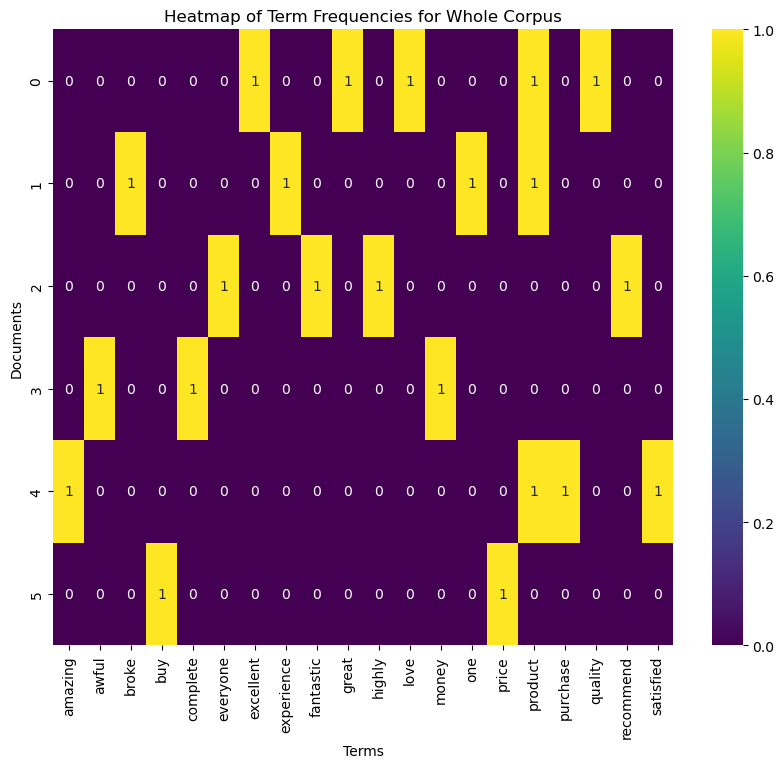

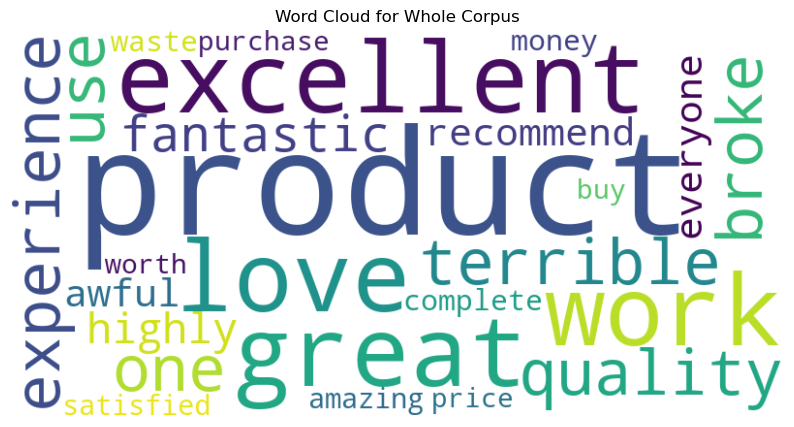

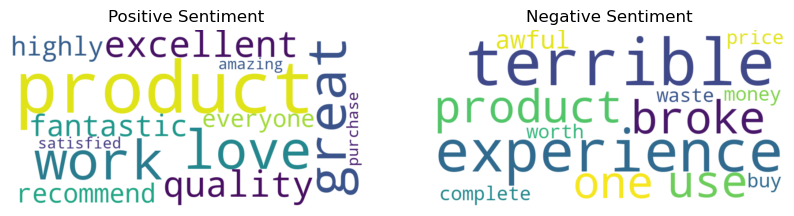

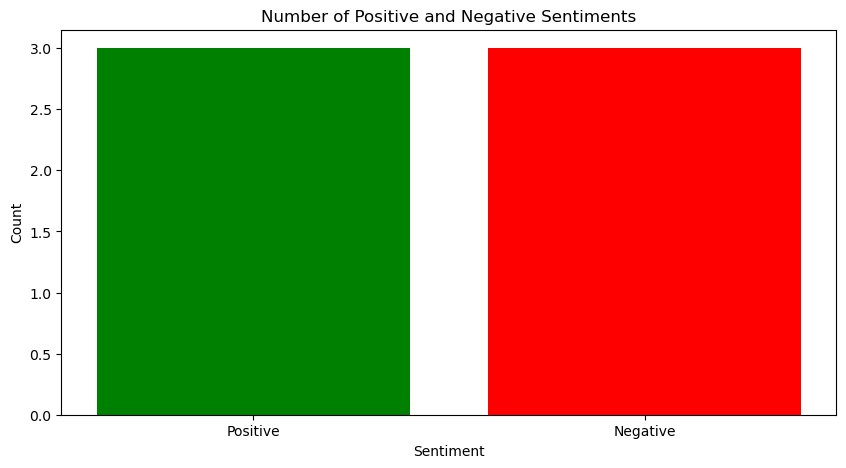

In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
# Read the CSV file
df = pd.read_csv('simple_dataset.csv')
# Initialize stemming and lemmatization objects
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
def preprocess_review(review):
 # Convert to lowercase
 review = review.lower()

 # Remove punctuations
 review = re.sub(r'[^\w\s]', '', review)

 # Remove numbers
 review = re.sub(r'\d+', '', review)

 # Tokenize words
 tokens = word_tokenize(review)

 # Remove stopwords
 stop_words = set(stopwords.words('english'))
 tokens = [word for word in tokens if word not in stop_words]

 # Perform stemming and lemmatization
 stemmed_tokens = [stemmer.stem(word) for word in tokens]
 lemmatized_tokens = [lemmatizer.lemmatize(word) for word in
tokens]

 # Join tokens into a single string
 preprocessed_review = ' '.join(lemmatized_tokens)

 return preprocessed_review
# Preprocess the reviews
df['preprocessed_text'] = df['text'].apply(preprocess_review)
display(df)
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df['preprocessed_text'])
term_freq_matrix = X.toarray()
terms = vectorizer.get_feature_names_out()
# Create Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(term_freq_matrix, xticklabels=terms, cmap='viridis',
annot=True)
plt.title("Heatmap of Term Frequencies for Whole Corpus")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()
all_text = " ".join(df['preprocessed_text'])
wordcloud = WordCloud(width=800, height=400, max_words=100,
background_color='white').generate(all_text)
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Whole Corpus")
plt.show()
# Generate word cloud for positive sentiment
positive_text = ' '.join(df[df['category'] ==
'Positive']['preprocessed_text'])
positive_wordcloud = WordCloud(width=800, height=400,
background_color='white').generate(positive_text)
# Generate word cloud for negative sentiment
negative_text = ' '.join(df[df['category'] ==
'Negative']['preprocessed_text'])
negative_wordcloud = WordCloud(width=800, height=400,
background_color='white').generate(negative_text)
# Display the word clouds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Sentiment')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Sentiment')
plt.axis('off')
plt.show()
# Bar Chart of Sentiment Counts
sentiment_counts = df['category'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values,
color=['green', 'red'])
plt.title('Number of Positive and Negative Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [ ]:
''' Insights:

1. Sentiment Distribution
The bar chart reveals a perfectly balanced dataset with an equal split of reviews:
* Positive Sentiments: 3 reviews (50%)
* Negative Sentiments: 3 reviews (50%)

This indicates that customer opinion is split exactly 50 50, 
showing no clear bias toward satisfaction or dissatisfaction.

2. Top Feedback Themes
The word clouds and term frequency analysis highlight two distinct vocabulary used by reviewers:
* Positive Keywords: Words like "excellent," "great," "love," "amazing," and "recommend" is top used. 
This states that satisfied customers focus on the quality and performance of the product.
* Negative Keywords: Words like "terrible," "awful," "waste," and "broke" most frequently used. 
This indicates that negative feedback is tied to product failure or a lack of value for money.

3. Key Term Overlap
The Heatmap and CountVectorizer results show that the word "product" appears in both positive and 
negative contexts.

* In positive reviews, it is associated with words like "love" and "amazing."

* In negative reviews, it is linked to issues like it "broke" or was a "waste."
This tells us that the feedback is highly based on product rather than service.


Reviews are contradictory for both sides which states different experiences, 
for some it broke and some doesnt which influence it to be a good product